In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv('cleaned_abstracts.csv')
df

,abstracts
0,Indoor photovoltaics are promising to enable s...
1,The energy loss in perovskite solar cells (PSC...
2,Organic–inorganic hybrid perovskite solar cell...
3,Heavily Br-doped PSCs have a segregation-free ...
4,A novel biphenyl fumaronitrile as an acceptor ...
...,...
3366,The stability of encapsulated planar-structure...
3367,Perovskite solar cells (PSCs) with mesoporous ...
3368,"In recent years, there has been an unprecedent..."
3369,Wide bandgap (Eg) perovskite solar cells (PSCs...


In [7]:
import pandas as pd

# Load your CSV
df = pd.read_csv('cleaned_abstracts.csv')

# Drop NaN or empty abstracts BEFORE embedding
df_clean = df.dropna().copy()
df_clean = df_clean[df_clean['abstracts'].str.strip().astype(bool)].reset_index(drop=True)

# Now df_clean.shape[0] should match embeddings.shape[0]
print(df_clean.shape)

(3371, 1)


In [9]:
!pip install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 20.2 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 21.0 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 21.9 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 21.8 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 19.4 MB/s eta 0:00:00m eta 0:00:010:01:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 21.6 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 21.8 MB/s eta 0:00:0031m22.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 20.7 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 22.0 MB/s eta 0:00:00MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 22.0 MB/s eta 0:00:00m eta 0:00:010:01:

In [11]:
import torch 

if torch.cuda.is_available():
    print("GPU is available")

In [13]:
df.shape

(3371, 1)

In [14]:
# embedding = np.load("stella_encoded_data.npy")
embedding = np.load("stella_embeddings.npy")

embedding.shape

(3371, 1024)

In [15]:
embedding[0]

array([-0.22475423,  0.34246272, -0.0339629 , ...,  0.07205345,
       -0.02839921, -0.11450056], dtype=float32)

In [24]:
# remember that the best so far was 55 
reducer = umap.UMAP(n_components=55,random_state=42)
reduced_data  = reducer.fit_transform(embedding)

In [25]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [22]:
embedding.shape

(3371, 1024)

In [23]:
reduced_data.shape

(3371, 55)

In [33]:
# remember that the best so far was 55 (For Agglomerative Clustering)
pca = PCA(n_components=55,random_state=42)
X_reduced = pca.fit_transform(embedding)

In [38]:
embedding.shape

(3371, 1024)

In [39]:
X_reduced.shape

(3371, 55)

In [34]:
linkage_matrix = linkage(X_reduced, method='ward')

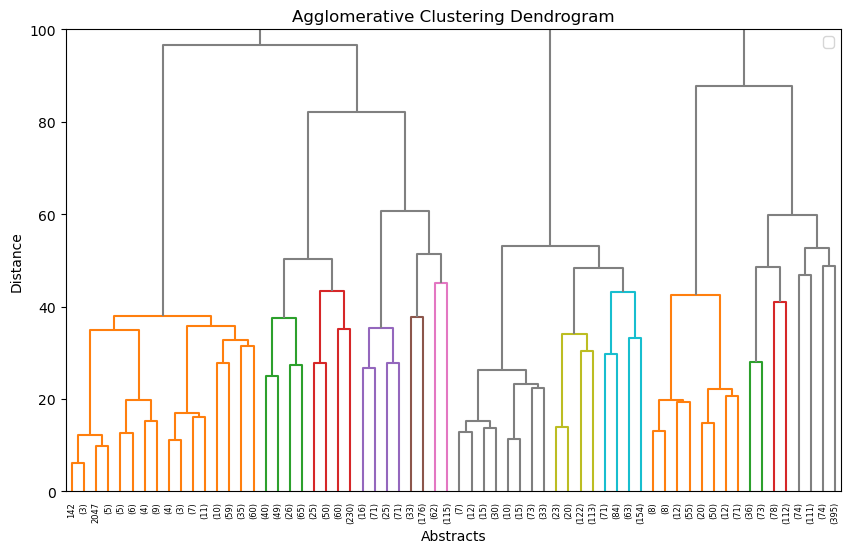

In [35]:
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Agglomerative clustering
clusterer = AgglomerativeClustering(n_clusters=15, linkage='ward')

# Create linkage matrix directly from the data (Ward method)
linkage_matrix = linkage(X_reduced, method='ward')

# Calculate correct threshold for 15 clusters
threshold_index = len(X_reduced) - 15 - 1
distance_threshold = linkage_matrix[threshold_index, 2]

plt.figure(figsize=(10, 6))

# above_threshold_color='gray' to show merged clusters
dendrogram(linkage_matrix, 
           truncate_mode='level', 
           p=5, 
           color_threshold=distance_threshold, 
           above_threshold_color='gray')        

plt.title("Agglomerative Clustering Dendrogram")
plt.xlabel("Abstracts")
plt.ylabel("Distance")
plt.legend()  
plt.ylim(0, 100)
plt.show()

In [37]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import PCA
from umap import UMAP
import plotly.graph_objects as go

# ============================================================
# CONFIG
# ============================================================

INPUT_FILE = "cleaned_abstracts.csv"
N_CLUSTERS = 15
DENDROGRAM_LEVELS = 5
n_components = 55  


STOPWORDS = {
    'a','an','the','of','for','with','on','at','by','from','to','i',
    'and','or','but','as','is','are','was','were','be','been','being',
    'have','has','had','can','will','would','could','should',
    'this','that','these','those','which','their','our','its',
    'using','used','use','based','showed','shown','show','we'
}

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv(INPUT_FILE)
abstracts = df["abstracts"].tolist()
n_abstracts = len(abstracts)

# ============================================================
# 2. AGGLOMERATIVE CLUSTERING
# ============================================================

vectorizer = TfidfVectorizer(max_features=1000, stop_words="english")
X = vectorizer.fit_transform(abstracts)

pca = PCA(n_components=55)
X_reduced = pca.fit_transform(embedding)

clusterer = AgglomerativeClustering(
    n_clusters=N_CLUSTERS,
    linkage="ward"
)
cluster_labels = clusterer.fit_predict(X_reduced)

linkage_matrix = linkage(X_reduced, method="ward")

threshold_index = len(X_reduced) - N_CLUSTERS - 1
distance_threshold = linkage_matrix[threshold_index, 2]

# ============================================================
# 3. BUILD FULL TREE
# ============================================================

node_members = {i: [i] for i in range(n_abstracts)}

for merge_idx, (l, r, _, _) in enumerate(linkage_matrix):
    node_id = n_abstracts + merge_idx
    node_members[node_id] = node_members[int(l)] + node_members[int(r)]

# Parent–child relations
merge_children = {}
merge_parent = {}

for merge_idx, (l, r, _, _) in enumerate(linkage_matrix):
    merge_children[merge_idx] = (int(l), int(r))
    if l >= n_abstracts:
        merge_parent[l - n_abstracts] = merge_idx
    if r >= n_abstracts:
        merge_parent[r - n_abstracts] = merge_idx

# ============================================================
# 4. DENDROGRAM
# ============================================================

dend = dendrogram(
    linkage_matrix,
    truncate_mode="level",
    p=DENDROGRAM_LEVELS,
    color_threshold=distance_threshold,
    no_plot=True
)

icoord = dend["icoord"]
dcoord = dend["dcoord"]

# ============================================================
# 5. SIBLING-AWARE c-TF-IDF
# ============================================================

def extract_keywords(node_indices, sibling_indices_list):
    node_doc = " ".join(abstracts[i] for i in node_indices)

    if not sibling_indices_list:
        tfidf = TfidfVectorizer(
            stop_words=list(STOPWORDS),
            ngram_range=(1, 3),
            max_features=500
        )
        scores = tfidf.fit_transform([node_doc]).toarray()[0]
        terms = tfidf.get_feature_names_out()
        top = scores.argsort()[-10:][::-1]
        return [terms[i] for i in top if scores[i] > 0]

    sibling_docs = [
        " ".join(abstracts[i] for i in sib)
        for sib in sibling_indices_list
    ]

    vectorizer = CountVectorizer(
        stop_words=list(STOPWORDS),
        ngram_range=(1, 3),
        max_features=1500
    )

    mat = vectorizer.fit_transform([node_doc] + sibling_docs)
    terms = vectorizer.get_feature_names_out()

    node_tf = mat[0].toarray().flatten()
    sib_tf = mat[1:].toarray()

    node_freq = node_tf / (node_tf.sum() + 1)
    sib_freq = sib_tf.mean(axis=0) / (sib_tf.sum(axis=1).mean() + 1)

    score = node_freq - sib_freq
    top = score.argsort()[-20:][::-1]

    return [
        terms[i] for i in top
        if score[i] > 0 and node_tf[i] >= 2
    ]

# ============================================================
# 6. UNIQUE LABEL GENERATION
# ============================================================

def make_label(keywords, used):
    if not keywords:
        return "General Research"

    phrases = [k for k in keywords if " " in k]
    singles = [k for k in keywords if " " not in k]

    def cap(w): return w.title()

    for p in phrases:
        label = " ".join(cap(w) for w in p.split())
        if label not in used:
            return label

    for i in range(min(5, len(singles)-1)):
        label = f"{cap(singles[i])} {cap(singles[i+1])}"
        if label not in used:
            return label

    base = cap(singles[0])
    k = 1
    while f"{base} {k}" in used:
        k += 1
    return f"{base} {k}"

# ============================================================
# 7. MAP VISIBLE NODES + UNIQUE LABELS + CLUSTER INFO
# ============================================================

visible_nodes = []
used_labels = set()

for xs, ys in zip(icoord, dcoord):
    h = max(ys)
    x = (xs[1] + xs[2]) / 2

    candidates = []
    for i, (_, _, dist, _) in enumerate(linkage_matrix):
        if abs(dist - h) < 1e-3:
            node_id = n_abstracts + i
            candidates.append((node_id, node_members[node_id]))

    if not candidates:
        continue

    node_id, members = max(candidates, key=lambda x: len(x[1]))

    siblings = []
    merge_idx = node_id - n_abstracts
    if merge_idx in merge_parent:
        p = merge_parent[merge_idx]
        l, r = merge_children[p]
        for s in (l, r):
            if s != node_id and s in node_members:
                siblings.append(node_members[s])

    keywords = extract_keywords(members, siblings)
    label = make_label(keywords, used_labels)
    used_labels.add(label)

    visible_nodes.append(dict(
        x=x,
        y=h,
        label=label,
        keywords=keywords,
        n=len(members),
        clusters=sorted(set(cluster_labels[i] for i in members)),
        samples=[abstracts[i][:200] for i in members[:5]]
    ))

# ============================================================
# 8. PLOTLY DENDROGRAM WITH CLUSTER AND ABSTRACT INFO
# ============================================================

fig = go.Figure()

for x, y in zip(icoord, dcoord):
    fig.add_trace(go.Scatter(
        x=x, y=y, mode="lines",
        line=dict(color="gray", width=1),
        hoverinfo="skip",
        showlegend=False
    ))

for n in visible_nodes:
    fig.add_trace(go.Scatter(
        x=[n["x"]], y=[n["y"]],
        mode="markers+text",
        marker=dict(size=7),
        text=n["label"],
        textposition="top center",
        hovertext=(
            f"<b>{n['label']}</b><br>"
            f"Number of Abstracts: {n['n']}<br>"
            f"Cluster(s): {n['clusters']}<br><br>"
            f"<b>All c-TF-IDF keywords:</b><br>"
            + ", ".join(n["keywords"]) +
            "<br><br>" +
            "<br>".join(n["samples"])
        ),
        hoverinfo="text",
        showlegend=False
    ))

fig.update_layout(
    title="Agglomerative Dendrogram with Unique Automatic Labels",
    xaxis=dict(showticklabels=False),
    yaxis=dict(title="Distance"),
    width=2200,
    height=1100
)

fig.write_html("interactive_dendrogram_full keywords.html", auto_open=True)

In [2]:
import pickle
import re
from pathlib import Path
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# ---------------------------------------------------------------
# Step 1: Load the dataset
# ---------------------------------------------------------------

df = pd.read_json("doi_list_meta_data.json")

# Remove rows where abstract is empty or missing
df = df[df["abstract"].notna()].copy()
df = df[df["abstract"].str.strip() != ""].copy()
df = df.reset_index(drop=True)

print(f"Total papers loaded: {len(df)}")


# ---------------------------------------------------------------
# Step 2: Clean the abstracts (remove XML tags)
# ---------------------------------------------------------------

def clean_abstract(text):
    text = re.sub(r"<[^>]+>", " ", text)   # remove tags like <jats:sub>
    text = re.sub(r"\s+", " ", text)        # remove extra spaces
    return text.strip()

df["abstract_clean"] = df["abstract"].apply(clean_abstract)

# Remove very short abstracts (less than 50 characters)
df = df[df["abstract_clean"].str.len() > 50].reset_index(drop=True)

print(f"Papers after cleaning: {len(df)}")


# ---------------------------------------------------------------
# Step 3: Build TF-IDF matrix (saved to disk after first run)
# ---------------------------------------------------------------

cache_file = "tfidf_cache.pkl"

if Path(cache_file).exists():
    print("Loading saved TF-IDF matrix...")
    with open(cache_file, "rb") as f:
        vectorizer, tfidf_matrix = pickle.load(f)
else:
    print("Building TF-IDF matrix for the first time (takes ~5 seconds)...")
    vectorizer = TfidfVectorizer(
        max_features = 5000,
        stop_words   = "english",
        ngram_range  = (1, 2)
    )
    tfidf_matrix = vectorizer.fit_transform(df["abstract_clean"].tolist())
    with open(cache_file, "wb") as f:
        pickle.dump((vectorizer, tfidf_matrix), f)
    print(f"Saved! Next time it will load instantly.")

print(f"Matrix ready: {tfidf_matrix.shape[0]} papers x {tfidf_matrix.shape[1]} features")


# ---------------------------------------------------------------
# Step 4: Find similar papers for a given abstract
# ---------------------------------------------------------------

def find_similar_papers(query, top_n=10):
    """
    Give this function either:
      - A row number  →  find_similar_papers(0)
      - Your own text →  find_similar_papers("perovskite solar cell...")
    """

    # Figure out if the user gave a number or text
    if isinstance(query, int):
        query_text = df.loc[query, "abstract_clean"]
        query_index = query
        print(f"\nFinding papers similar to paper #{query}")
        print(f"Title: {df.loc[query, 'title']}")
        print("-" * 60)
    else:
        query_text = clean_abstract(query)
        query_index = None
        print(f"\nFinding papers similar to your text...")
        print(f"Preview: {query_text[:100]}...")
        print("-" * 60)

    # Convert the query into TF-IDF vector
    query_vector = vectorizer.transform([query_text])

    # Calculate similarity between query and all papers
    similarity_scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

    # Don't return the query paper itself
    if query_index is not None:
        similarity_scores[query_index] = 0

    # Get the top N most similar papers
    top_indices = similarity_scores.argsort()[::-1][:top_n]

    # Print the results
    print(f"\nTop {top_n} similar papers:\n")

    for rank, idx in enumerate(top_indices, start=1):
        score = similarity_scores[idx]
        title = df.loc[idx, "title"]
        doi   = df.loc[idx, "doi"]
        abstract_preview = df.loc[idx, "abstract_clean"][:200]

        print(f"[{rank}] Similarity Score: {score:.4f}")
        print(f"     Title    : {title}")
        print(f"     DOI Link : https://doi.org/{doi}")
        print(f"     Abstract : {abstract_preview}...")
        print()


# ---------------------------------------------------------------
# Step 5: Run it!
# ---------------------------------------------------------------

# Option A: Give a row number from the dataset
find_similar_papers(0, top_n=10)

# Option B: Paste your own abstract text (uncomment to use)
# my_abstract = """
# Write your abstract here. The function will find the most
# similar papers from the dataset.
# """
# find_similar_papers(my_abstract, top_n=10)

Total papers loaded: 3373
Papers after cleaning: 3371
Building TF-IDF matrix for the first time (takes ~5 seconds)...
Saved! Next time it will load instantly.
Matrix ready: 3371 papers x 5000 features

Finding papers similar to paper #0
Title: Tailoring Triple‐Anion Perovskite Material for Indoor Light Harvesting with Restrained Halide Segregation and Record High Efficiency Beyond 36%
------------------------------------------------------------

Top 10 similar papers:

[1] Similarity Score: 0.3288
     Title    : Interface Modification by Ionic Liquid: A Promising Candidate for Indoor Light Harvesting and Stability Improvement of Planar Perovskite Solar Cells
     DOI Link : https://doi.org/10.1002/aenm.201801509
     Abstract : Organic–inorganic hybrid perovskite solar cells (PSCs) are currently attracting significant interest owing to their promising outdoor performance. However, the ability of indoor light harvesting of th...

[2] Similarity Score: 0.3036
     Title    : Outstanding

In [3]:
import pickle
import re
from pathlib import Path
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# ---------------------------------------------------------------
# CONFIGURATION — Change these to match your dataset
# ---------------------------------------------------------------

FILE_PATH       = "doi_list_meta_data.json"   # supports .json, .csv, .xlsx

ABSTRACT_COLUMN = "abstract"    # column name that contains the abstract text
TITLE_COLUMN    = "title"       # column name that contains the paper title
DOI_COLUMN      = "doi"         # column name that contains the DOI (set None if not available)

TOP_N           = 5             # how many similar papers to find for each abstract

# ---------------------------------------------------------------


# ---------------------------------------------------------------
# Step 1: Load any file format automatically
# ---------------------------------------------------------------

def load_file(filepath):
    ext = Path(filepath).suffix.lower()

    if ext == ".json":
        df = pd.read_json(filepath)
    elif ext == ".csv":
        df = pd.read_csv(filepath)
    elif ext in [".xlsx", ".xls"]:
        df = pd.read_excel(filepath)
    else:
        raise ValueError(f"Unsupported file format: {ext}. Use .json, .csv, or .xlsx")

    print(f"Loaded file   : {filepath}")
    print(f"Total rows    : {len(df)}")
    print(f"Columns found : {list(df.columns)}")
    return df


df = load_file(FILE_PATH)


# ---------------------------------------------------------------
# Step 2: Validate columns exist in the dataset
# ---------------------------------------------------------------

# Check abstract column exists
if ABSTRACT_COLUMN not in df.columns:
    print(f"\nERROR: Column '{ABSTRACT_COLUMN}' not found in your dataset.")
    print(f"Available columns are: {list(df.columns)}")
    print(f"Please update ABSTRACT_COLUMN at the top of the script.")
    raise SystemExit

# Check title column exists
if TITLE_COLUMN not in df.columns:
    print(f"\nWARNING: Column '{TITLE_COLUMN}' not found. Using row index as title.")
    df["_title"] = ["Paper_" + str(i) for i in range(len(df))]
    TITLE_COLUMN = "_title"

# Check DOI column exists
if DOI_COLUMN and DOI_COLUMN not in df.columns:
    print(f"\nWARNING: Column '{DOI_COLUMN}' not found. DOI links will be skipped.")
    DOI_COLUMN = None

print(f"\nUsing columns:")
print(f"  Abstract : '{ABSTRACT_COLUMN}'")
print(f"  Title    : '{TITLE_COLUMN}'")
print(f"  DOI      : '{DOI_COLUMN if DOI_COLUMN else 'not available'}'")


# ---------------------------------------------------------------
# Step 3: Clean the abstracts (remove XML/HTML tags)
# ---------------------------------------------------------------

def clean_abstract(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<[^>]+>", " ", text)   # remove XML/HTML tags
    text = re.sub(r"&[a-z]+;", " ", text)   # remove HTML entities
    text = re.sub(r"\s+", " ", text)         # remove extra spaces
    return text.strip()

df["abstract_clean"] = df[ABSTRACT_COLUMN].apply(clean_abstract)

# Remove rows where abstract is empty or too short
before = len(df)
df = df[df["abstract_clean"].str.len() > 50].reset_index(drop=True)
after = len(df)

print(f"\nAbstracts after cleaning : {after}  (removed {before - after} empty/short rows)")


# ---------------------------------------------------------------
# Step 4: Build TF-IDF matrix (saved to disk, reused next time)
# ---------------------------------------------------------------

# Cache file is named after your input file so different datasets
# don't overwrite each other's cache
cache_file = Path(FILE_PATH).stem + "_tfidf_cache.pkl"

if Path(cache_file).exists():
    print(f"\nLoading saved TF-IDF matrix from '{cache_file}'...")
    with open(cache_file, "rb") as f:
        vectorizer, tfidf_matrix = pickle.load(f)

    # If dataset changed, rebuild the cache
    if tfidf_matrix.shape[0] != len(df):
        print("Dataset size changed — rebuilding cache...")
        Path(cache_file).unlink()
        vectorizer = TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1, 2))
        tfidf_matrix = vectorizer.fit_transform(df["abstract_clean"].tolist())
        with open(cache_file, "wb") as f:
            pickle.dump((vectorizer, tfidf_matrix), f)
else:
    print(f"\nBuilding TF-IDF matrix (first time only, ~5 seconds)...")
    vectorizer = TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1, 2))
    tfidf_matrix = vectorizer.fit_transform(df["abstract_clean"].tolist())
    with open(cache_file, "wb") as f:
        pickle.dump((vectorizer, tfidf_matrix), f)
    print(f"Saved to '{cache_file}' — loads instantly next time.")

print(f"Matrix ready: {tfidf_matrix.shape[0]} papers x {tfidf_matrix.shape[1]} features\n")


# ---------------------------------------------------------------
# Step 5: Find similar papers for ALL abstracts and save to CSV
# ---------------------------------------------------------------

print(f"Finding top {TOP_N} similar papers for each abstract...")
print("-" * 50)

all_results = []
total = len(df)

for i in range(total):

    if i % 100 == 0:
        print(f"  Processing {i} / {total} ...")

    # Convert this abstract into a TF-IDF vector
    query_vector = vectorizer.transform([df.loc[i, "abstract_clean"]])

    # Calculate similarity against all abstracts
    similarity_scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

    # Exclude the paper itself
    similarity_scores[i] = 0

    # Get top N most similar
    top_indices = similarity_scores.argsort()[::-1][:TOP_N]

    for rank, similar_idx in enumerate(top_indices, start=1):
        score = similarity_scores[similar_idx]
        if score <= 0:
            continue

        row = {
            "query_index"      : i,
            "query_title"      : df.loc[i, TITLE_COLUMN],
            "rank"             : rank,
            "similar_score"    : round(score, 4),
            "similar_title"    : df.loc[similar_idx, TITLE_COLUMN],
            "similar_abstract" : df.loc[similar_idx, "abstract_clean"][:300],
        }

        # Add DOI info only if available
        if DOI_COLUMN:
            row["query_doi"]        = df.loc[i, DOI_COLUMN]
            row["similar_doi"]      = df.loc[similar_idx, DOI_COLUMN]
            row["similar_doi_link"] = f"https://doi.org/{df.loc[similar_idx, DOI_COLUMN]}"

        all_results.append(row)

print(f"\nDone! Processed {total} abstracts.")


# ---------------------------------------------------------------
# Step 6: Save results to CSV
# ---------------------------------------------------------------

output_file = Path(FILE_PATH).stem + "_similar_papers.csv"
results_df  = pd.DataFrame(all_results)
results_df.to_csv(output_file, index=False)

print(f"Total rows saved : {len(results_df)}")
print(f"Output file      : {output_file}")


# ---------------------------------------------------------------
# Step 7: Quick lookup — show similar papers for any one paper
# ---------------------------------------------------------------

def show_similar_for(query, top_n=10):
    """
    Show similar papers for one specific paper after the full run.

    Usage:
        show_similar_for(0)                  # by row index
        show_similar_for("10.1002/...")      # by DOI  (only if DOI column exists)
        show_similar_for("perovskite...")    # by pasting your own abstract text
    """

    if isinstance(query, int):
        # Look up by row index from the saved results
        subset = results_df[results_df["query_index"] == query].head(top_n)
        print(f"\nSimilar papers for paper #{query}")
        print(f"Title: {df.loc[query, TITLE_COLUMN]}\n")

    elif DOI_COLUMN and query in results_df.get("query_doi", pd.Series()).values:
        # Look up by DOI
        subset = results_df[results_df["query_doi"] == query].head(top_n)
        print(f"\nSimilar papers for DOI: {query}\n")

    else:
        # Treat it as raw abstract text — run a fresh similarity search
        print(f"\nRunning fresh search for custom abstract text...\n")
        query_vector     = vectorizer.transform([clean_abstract(query)])
        similarity_scores = cosine_similarity(query_vector, tfidf_matrix).flatten()
        top_indices      = similarity_scores.argsort()[::-1][:top_n]

        print(f"Top {top_n} similar papers:\n")
        for rank, idx in enumerate(top_indices, start=1):
            score = similarity_scores[idx]
            if score <= 0:
                break
            doi_line = f"https://doi.org/{df.loc[idx, DOI_COLUMN]}" if DOI_COLUMN else "N/A"
            print(f"[{rank}] Score: {score:.4f}")
            print(f"     Title : {df.loc[idx, TITLE_COLUMN]}")
            print(f"     Link  : {doi_line}")
            print()
        return

    if subset.empty:
        print("No results found.")
        return

    for _, row in subset.iterrows():
        doi_line = row.get("similar_doi_link", "N/A")
        print(f"[{int(row['rank'])}] Score: {row['similar_score']}")
        print(f"     Title : {row['similar_title']}")
        print(f"     Link  : {doi_line}")
        print()


# ---------------------------------------------------------------
# Example usage — change the index or paste your own text
# ---------------------------------------------------------------

# Show similar papers for paper at index 0
show_similar_for(0)

# Show for a different paper
# show_similar_for(50)

# Paste your own abstract text from a completely different dataset
# show_similar_for("your abstract text from any source here...")

Loaded file   : doi_list_meta_data.json
Total rows    : 7471
Columns found : ['doi', 'title', 'abstract']

Using columns:
  Abstract : 'abstract'
  Title    : 'title'
  DOI      : 'doi'

Abstracts after cleaning : 3371  (removed 4100 empty/short rows)

Building TF-IDF matrix (first time only, ~5 seconds)...
Saved to 'doi_list_meta_data_tfidf_cache.pkl' — loads instantly next time.
Matrix ready: 3371 papers x 5000 features

Finding top 5 similar papers for each abstract...
--------------------------------------------------
  Processing 0 / 3371 ...
  Processing 100 / 3371 ...
  Processing 200 / 3371 ...
  Processing 300 / 3371 ...
  Processing 400 / 3371 ...
  Processing 500 / 3371 ...
  Processing 600 / 3371 ...
  Processing 700 / 3371 ...
  Processing 800 / 3371 ...
  Processing 900 / 3371 ...
  Processing 1000 / 3371 ...
  Processing 1100 / 3371 ...
  Processing 1200 / 3371 ...
  Processing 1300 / 3371 ...
  Processing 1400 / 3371 ...
  Processing 1500 / 3371 ...
  Processing 1600 / 

In [4]:
import os
from IPython.display import FileLink

output_file = "doi_list_meta_data_similar_papers.csv"
print("Full path:", os.path.abspath(output_file))

# Clickable download link inside Jupyter
FileLink(output_file)

Full path: /home/yummareddy/Literature-Integration-Prototype/embeddings_clustering/doi_list_meta_data_similar_papers.csv


/home/yummareddy/Literature-Integration-Prototype/embeddings_clustering/doi_list_meta_data_similar_papers.csv

In [1]:
pip install arxiv

Note: you may need to restart the kernel to use updated packages.


In [1]:
import re
import time
import pickle
from pathlib import Path

import requests
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from tools import post_data
from project_variable import variables


# ---------------------------------------------------------------
# CONFIG  — only change these
# ---------------------------------------------------------------

DATA_FILE        = "doi_list_meta_data.json"   # your existing 3,371 papers
CACHE_FILE       = "tfidf_cache.pkl"
NEW_PAPERS_CACHE = "new_nomad_papers.csv"       # saves fetched papers so you dont re-fetch
OUTPUT_FILE      = "grouped_similar_abstracts.csv"

MAX_NEW_PAGES    = 5     # pages to fetch from NOMAD (1 page = 1000 entries)
TOP_N            = 5     # how many similar abstracts to return per paper


# ---------------------------------------------------------------
# Step 1: Clean text helper
# ---------------------------------------------------------------

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"&[a-z]+;", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# ---------------------------------------------------------------
# Step 2: Load your existing 3,371 papers
# ---------------------------------------------------------------

print("=" * 60)
print("STEP 1: Loading existing 3,371 papers")
print("=" * 60)

df_existing = pd.read_json(DATA_FILE)
df_existing = df_existing[df_existing["abstract"].notna()].copy()
df_existing = df_existing[df_existing["abstract"].str.strip() != ""].copy()
df_existing["abstract_clean"] = df_existing["abstract"].apply(clean_text)
df_existing = df_existing[df_existing["abstract_clean"].str.len() > 50].reset_index(drop=True)
df_existing["source"] = "existing"

existing_dois = set(df_existing["doi"].dropna().str.strip().str.lower().tolist())

print(f"Existing papers loaded: {len(df_existing)}\n")


# ---------------------------------------------------------------
# Step 3: Fetch new NOMAD entries and get their abstracts
#         (skipped if new_nomad_papers.csv already exists)
# ---------------------------------------------------------------

def fetch_abstract_from_crossref(doi):
    url = f"https://api.crossref.org/works/{doi}"
    try:
        r        = requests.get(url, timeout=10)
        msg      = r.json().get("message", {})
        title    = (msg.get("title") or [""])[0]
        abstract = clean_text(msg.get("abstract", "") or "")
        return title, abstract
    except Exception:
        return "", ""


def fetch_new_nomad_papers(max_pages=MAX_NEW_PAGES):
    print("=" * 60)
    print("STEP 2: Fetching new NOMAD entries")
    print("=" * 60)

    new_dois   = []
    page_value = None

    for page_num in range(1, max_pages + 1):

        data = {
            "owner": "visible",
            "query": {
                "and": [
                    {},
                    {"sections:all": ["nomad.datamodel.results.SolarCell"]}
                ]
            },
            "aggregations": {},
            "pagination": {
                "order_by"         : "results.properties.optoelectronic.solar_cell.efficiency",
                "order"            : "desc",
                "page_size"        : 1000,
                "page_after_value" : page_value
            },
            "required": {
                "exclude": ["quantities", "sections", "files"]
            }
        }

        response  = post_data(variables["POST_META_DATA"], data)
        next_page = response["pagination"].get("next_page_after_value")
        entries   = response.get("data", [])

        for entry in entries:
            refs = entry.get("references", [])
            if not refs:
                continue
            doi = refs[0].strip().lower()
            if doi and doi not in existing_dois:
                new_dois.append(doi)

        print(f"  Page {page_num}: {len(new_dois)} new DOIs collected so far...")

        if not next_page:
            print("  No more pages in NOMAD.")
            break
        page_value = next_page

    # Remove duplicates
    new_dois = list(set(new_dois))
    print(f"\nTotal unique new DOIs: {len(new_dois)}")
    print("Fetching abstracts from CrossRef (one by one)...\n")

    new_papers = []
    for i, doi in enumerate(new_dois):
        if i % 50 == 0:
            print(f"  CrossRef: {i} / {len(new_dois)} ...")
        title, abstract = fetch_abstract_from_crossref(doi)
        if abstract and len(abstract) > 50:
            new_papers.append({
                "doi"            : doi,
                "title"          : title,
                "abstract"       : abstract,
                "abstract_clean" : clean_text(abstract),
                "source"         : "new_from_nomad"
            })
        time.sleep(0.1)   # polite delay

    new_df = pd.DataFrame(new_papers)
    new_df.to_csv(NEW_PAPERS_CACHE, index=False)
    print(f"\nNew papers with abstracts: {len(new_df)}")
    print(f"Saved to '{NEW_PAPERS_CACHE}' (won't re-fetch next time)\n")
    return new_df


# Load new papers from cache if already fetched, else fetch fresh
if Path(NEW_PAPERS_CACHE).exists():
    print("=" * 60)
    print("STEP 2: Loading already fetched new NOMAD papers from cache")
    print("=" * 60)
    df_new = pd.read_csv(NEW_PAPERS_CACHE)
    df_new["abstract_clean"] = df_new["abstract"].apply(clean_text)
    print(f"New papers loaded from cache: {len(df_new)}\n")
else:
    df_new = fetch_new_nomad_papers(max_pages=MAX_NEW_PAGES)


# ---------------------------------------------------------------
# Step 4: Combine existing 3,371 + newly fetched into one pool
# ---------------------------------------------------------------

print("=" * 60)
print("STEP 3: Building combined pool")
print("=" * 60)

df_pool = pd.concat(
    [df_existing[["doi", "title", "abstract", "abstract_clean", "source"]],
     df_new[["doi", "title", "abstract", "abstract_clean", "source"]]],
    ignore_index=True
)

print(f"Existing papers    : {len(df_existing)}")
print(f"New NOMAD papers   : {len(df_new)}")
print(f"Combined pool size : {len(df_pool)}\n")


# ---------------------------------------------------------------
# Step 5: Build TF-IDF on the FULL combined pool
# ---------------------------------------------------------------

print("=" * 60)
print("STEP 4: Building TF-IDF on combined pool")
print("=" * 60)

# Always rebuild when pool changes
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
    sublinear_tf=True
)
pool_matrix = vectorizer.fit_transform(df_pool["abstract_clean"].tolist())
print(f"Matrix ready: {pool_matrix.shape}\n")


# ---------------------------------------------------------------
# Step 6: For each of the 3,371 abstracts, find TOP_N similar
#         abstracts from the combined pool (excluding itself)
# ---------------------------------------------------------------

print("=" * 60)
print(f"STEP 5: Finding top {TOP_N} similar abstracts for each of your {len(df_existing)} papers")
print("=" * 60)

all_results = []

for i in range(len(df_existing)):

    if i % 200 == 0:
        print(f"  Processing {i} / {len(df_existing)} ...")

    query_vec = vectorizer.transform([df_existing.loc[i, "abstract_clean"]])
    scores    = cosine_similarity(query_vec, pool_matrix).flatten()

    # Exclude the paper itself (it exists at position i in the pool)
    scores[i] = 0

    top_indices = scores.argsort()[::-1][:TOP_N]

    for rank, idx in enumerate(top_indices, start=1):
        score = float(scores[idx])
        if score <= 0:
            break

        all_results.append({
            # --- query paper ---
            "query_index"      : i,
            "query_doi"        : df_existing.loc[i, "doi"],
            "query_title"      : df_existing.loc[i, "title"],
            "query_abstract"   : df_existing.loc[i, "abstract_clean"][:300],

            # --- similar paper ---
            "rank"             : rank,
            "similarity_score" : round(score, 4),
            "similar_source"   : df_pool.loc[idx, "source"],   # existing or new_from_nomad
            "similar_doi"      : df_pool.loc[idx, "doi"],
            "similar_doi_link" : f"https://doi.org/{df_pool.loc[idx, 'doi']}",
            "similar_title"    : df_pool.loc[idx, "title"],
            "similar_abstract" : df_pool.loc[idx, "abstract_clean"][:300],
        })

print(f"\nDone!")


# ---------------------------------------------------------------
# Step 7: Save to CSV
# ---------------------------------------------------------------

print("=" * 60)
print("STEP 6: Saving results")
print("=" * 60)

results_df = pd.DataFrame(all_results)
results_df.to_csv(OUTPUT_FILE, index=False)

print(f"Total rows          : {len(results_df)}")
print(f"Output file         : {OUTPUT_FILE}")
print(f"Papers covered      : {results_df['query_index'].nunique()}")
print(f"New NOMAD papers    : {(results_df['similar_source'] == 'new_from_nomad').sum()} results came from new papers\n")


# ---------------------------------------------------------------
# Step 8: Quick lookup — see similar abstracts for any one paper
# ---------------------------------------------------------------

def show_similar_for(query):
    """
    Show the grouped similar abstracts for one paper.

    Usage:
        show_similar_for(0)              # by row index
        show_similar_for("10.1002/...")  # by DOI
    """
    if isinstance(query, int):
        subset = results_df[results_df["query_index"] == query]
        print(f"\nQuery paper #{query}")
        print(f"Title   : {df_existing.loc[query, 'title']}")
        print(f"Abstract: {df_existing.loc[query, 'abstract_clean'][:200]}...")
    else:
        subset = results_df[results_df["query_doi"] == query]
        print(f"\nQuery DOI: {query}")

    print(f"\n--- {len(subset)} Similar abstracts from NOMAD pool ---\n")

    for _, row in subset.iterrows():
        print(f"[{int(row['rank'])}] Score  : {row['similarity_score']}  |  Source: {row['similar_source']}")
        print(f"     Title  : {row['similar_title']}")
        print(f"     Link   : {row['similar_doi_link']}")
        print(f"     Abstract: {row['similar_abstract'][:200]}...")
        print()


# Show example
show_similar_for(0)

STEP 1: Loading existing 3,371 papers
Existing papers loaded: 3371

STEP 2: Fetching new NOMAD entries
  Page 1: 993 new DOIs collected so far...
  Page 2: 1982 new DOIs collected so far...
  Page 3: 2972 new DOIs collected so far...
  Page 4: 3969 new DOIs collected so far...
  Page 5: 4962 new DOIs collected so far...

Total unique new DOIs: 2191
Fetching abstracts from CrossRef (one by one)...

  CrossRef: 0 / 2191 ...
  CrossRef: 50 / 2191 ...
  CrossRef: 100 / 2191 ...
  CrossRef: 150 / 2191 ...
  CrossRef: 200 / 2191 ...
  CrossRef: 250 / 2191 ...
  CrossRef: 300 / 2191 ...
  CrossRef: 350 / 2191 ...
  CrossRef: 400 / 2191 ...
  CrossRef: 450 / 2191 ...
  CrossRef: 500 / 2191 ...
  CrossRef: 550 / 2191 ...
  CrossRef: 600 / 2191 ...
  CrossRef: 650 / 2191 ...
  CrossRef: 700 / 2191 ...
  CrossRef: 750 / 2191 ...
  CrossRef: 800 / 2191 ...
  CrossRef: 850 / 2191 ...
  CrossRef: 900 / 2191 ...
  CrossRef: 950 / 2191 ...
  CrossRef: 1000 / 2191 ...
  CrossRef: 1050 / 2191 ...
  Cros

In [2]:
import re
import time
import pickle
from pathlib import Path

import requests
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from tools import post_data
from project_variable import variables


# ---------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------

DATA_FILE        = "doi_list_meta_data.json"   # your existing 3,371 papers
NEW_PAPERS_CACHE = "new_nomad_papers.csv"       # fetched once, reused every time
OUTPUT_FILE      = "similar_abstracts_from_nomad.csv"

MAX_NEW_PAGES    = 5    # pages to fetch from NOMAD  (1 page = 1000 entries)
TOP_N            = 5    # how many similar abstracts to return per paper


# ---------------------------------------------------------------
# Helper
# ---------------------------------------------------------------

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"&[a-z]+;", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# ---------------------------------------------------------------
# STEP 1 — Load your existing 3,371 papers  (QUERY side only)
# ---------------------------------------------------------------

print("=" * 60)
print("STEP 1: Loading your 3,371 existing papers (query side)")
print("=" * 60)

df_query = pd.read_json(DATA_FILE)
df_query = df_query[df_query["abstract"].notna()].copy()
df_query = df_query[df_query["abstract"].str.strip() != ""].copy()
df_query["abstract_clean"] = df_query["abstract"].apply(clean_text)
df_query = df_query[df_query["abstract_clean"].str.len() > 50].reset_index(drop=True)

# Store their DOIs so we never return them as results
existing_dois = set(df_query["doi"].dropna().str.strip().str.lower().tolist())

print(f"Query papers loaded : {len(df_query)}")
print(f"Their DOIs stored   : {len(existing_dois)}  (will never appear in results)\n")


# ---------------------------------------------------------------
# STEP 2 — Fetch brand new NOMAD papers  (SEARCH POOL side only)
#           Saved to CSV after first run — never re-fetches
# ---------------------------------------------------------------

def fetch_abstract_from_crossref(doi):
    url = f"https://api.crossref.org/works/{doi}"
    try:
        r        = requests.get(url, timeout=10)
        msg      = r.json().get("message", {})
        title    = (msg.get("title") or [""])[0]
        abstract = clean_text(msg.get("abstract", "") or "")
        return title, abstract
    except Exception:
        return "", ""


def fetch_new_nomad_papers():
    print("=" * 60)
    print("STEP 2: Fetching new NOMAD entries")
    print("=" * 60)

    new_dois   = []
    page_value = None

    for page_num in range(1, MAX_NEW_PAGES + 1):

        data = {
            "owner": "visible",
            "query": {
                "and": [
                    {},
                    {"sections:all": ["nomad.datamodel.results.SolarCell"]}
                ]
            },
            "aggregations": {},
            "pagination": {
                "order_by"         : "results.properties.optoelectronic.solar_cell.efficiency",
                "order"            : "desc",
                "page_size"        : 1000,
                "page_after_value" : page_value
            },
            "required": {
                "exclude": ["quantities", "sections", "files"]
            }
        }

        response  = post_data(variables["POST_META_DATA"], data)
        next_page = response["pagination"].get("next_page_after_value")
        entries   = response.get("data", [])

        for entry in entries:
            refs = entry.get("references", [])
            if not refs:
                continue
            doi = refs[0].strip().lower()

            # ONLY keep DOIs that are NOT in your existing 3,371
            if doi and doi not in existing_dois:
                new_dois.append(doi)

        print(f"  Page {page_num}: {len(new_dois)} new DOIs collected...")

        if not next_page:
            print("  No more pages.")
            break
        page_value = next_page

    # Remove duplicates
    new_dois = list(set(new_dois))
    print(f"\nUnique new DOIs from NOMAD : {len(new_dois)}")
    print("Fetching abstracts via CrossRef...\n")

    new_papers = []
    for i, doi in enumerate(new_dois):
        if i % 50 == 0:
            print(f"  CrossRef: {i} / {len(new_dois)} ...")
        title, abstract = fetch_abstract_from_crossref(doi)
        if abstract and len(abstract) > 50:
            new_papers.append({
                "doi"            : doi,
                "doi_link"       : f"https://doi.org/{doi}",
                "title"          : title,
                "abstract"       : abstract,
                "abstract_clean" : clean_text(abstract)
            })
        time.sleep(0.1)

    df_new = pd.DataFrame(new_papers)
    df_new.to_csv(NEW_PAPERS_CACHE, index=False)
    print(f"\nNew NOMAD papers with abstracts : {len(df_new)}")
    print(f"Saved to '{NEW_PAPERS_CACHE}'  (won't re-fetch next run)\n")
    return df_new


# Load from cache if already fetched, else fetch fresh
if Path(NEW_PAPERS_CACHE).exists():
    print("=" * 60)
    print("STEP 2: Loading new NOMAD papers from cache")
    print("=" * 60)
    df_nomad = pd.read_csv(NEW_PAPERS_CACHE)
    df_nomad["abstract_clean"] = df_nomad["abstract"].apply(clean_text)
    df_nomad = df_nomad.reset_index(drop=True)
    print(f"New NOMAD papers loaded : {len(df_nomad)}\n")
else:
    df_nomad = fetch_new_nomad_papers()


# ---------------------------------------------------------------
# STEP 3 — Build TF-IDF ONLY on the new NOMAD papers
#           (your 3,371 are NOT included here)
# ---------------------------------------------------------------

print("=" * 60)
print("STEP 3: Building TF-IDF on new NOMAD papers only")
print("=" * 60)

vectorizer = TfidfVectorizer(
    max_features = 5000,
    stop_words   = "english",
    ngram_range  = (1, 2),
    sublinear_tf = True
)
nomad_matrix = vectorizer.fit_transform(df_nomad["abstract_clean"].tolist())

print(f"Matrix shape : {nomad_matrix.shape}")
print(f"  Rows = {nomad_matrix.shape[0]} new NOMAD papers")
print(f"  Cols = {nomad_matrix.shape[1]} TF-IDF features\n")


# ---------------------------------------------------------------
# STEP 4 — For each of your 3,371 abstracts
#           find TOP_N similar abstracts from new NOMAD papers
# ---------------------------------------------------------------

print("=" * 60)
print(f"STEP 4: Matching each of your {len(df_query)} abstracts")
print(f"        against {len(df_nomad)} new NOMAD abstracts")
print("=" * 60)

all_results = []

for i in range(len(df_query)):

    if i % 200 == 0:
        print(f"  Processing {i} / {len(df_query)} ...")

    # Transform this query abstract using the NOMAD vectorizer
    query_vec = vectorizer.transform([df_query.loc[i, "abstract_clean"]])

    # Compare against all new NOMAD abstracts
    scores    = cosine_similarity(query_vec, nomad_matrix).flatten()

    # Get top N most similar
    top_indices = scores.argsort()[::-1][:TOP_N]

    for rank, idx in enumerate(top_indices, start=1):
        score = float(scores[idx])
        if score <= 0:
            break

        all_results.append({
            # your abstract (query)
            "query_index"      : i,
            "query_doi"        : df_query.loc[i, "doi"],
            "query_title"      : df_query.loc[i, "title"],
            "query_abstract"   : df_query.loc[i, "abstract_clean"][:300],

            # similar abstract from NEW NOMAD papers
            "rank"             : rank,
            "similarity_score" : round(score, 4),
            "nomad_doi"        : df_nomad.loc[idx, "doi"],
            "nomad_doi_link"   : df_nomad.loc[idx, "doi_link"],
            "nomad_title"      : df_nomad.loc[idx, "title"],
            "nomad_abstract"   : df_nomad.loc[idx, "abstract_clean"][:300],
        })

print(f"\nDone!\n")


# ---------------------------------------------------------------
# STEP 5 — Save results
# ---------------------------------------------------------------

print("=" * 60)
print("STEP 5: Saving results")
print("=" * 60)

results_df = pd.DataFrame(all_results)
results_df.to_csv(OUTPUT_FILE, index=False)

print(f"Total rows    : {len(results_df)}")
print(f"Papers covered: {results_df['query_index'].nunique()} out of {len(df_query)}")
print(f"Output file   : {OUTPUT_FILE}\n")


# ---------------------------------------------------------------
# Quick lookup — see results for any one abstract
# ---------------------------------------------------------------

def show_similar_for(query):
    """
    Show similar NOMAD abstracts for one specific paper.

    Usage:
        show_similar_for(0)              # by row index
        show_similar_for("10.1002/...")  # by DOI
    """
    if isinstance(query, int):
        subset = results_df[results_df["query_index"] == query]
        print(f"\nYour paper #{query}")
        print(f"Title   : {df_query.loc[query, 'title']}")
        print(f"Abstract: {df_query.loc[query, 'abstract_clean'][:200]}...")
    else:
        subset = results_df[results_df["query_doi"] == query]
        print(f"\nYour paper DOI: {query}")

    print(f"\n--- Top {len(subset)} similar abstracts from NOMAD ---\n")

    for _, row in subset.iterrows():
        print(f"[{int(row['rank'])}] Score    : {row['similarity_score']}")
        print(f"     Title    : {row['nomad_title']}")
        print(f"     DOI Link : {row['nomad_doi_link']}")
        print(f"     Abstract : {row['nomad_abstract'][:200]}...")
        print()


# Show example for first paper
show_similar_for(0)

STEP 1: Loading your 3,371 existing papers (query side)
Query papers loaded : 3371
Their DOIs stored   : 3332  (will never appear in results)

STEP 2: Loading new NOMAD papers from cache
New NOMAD papers loaded : 1283

STEP 3: Building TF-IDF on new NOMAD papers only
Matrix shape : (1283, 5000)
  Rows = 1283 new NOMAD papers
  Cols = 5000 TF-IDF features

STEP 4: Matching each of your 3371 abstracts
        against 1283 new NOMAD abstracts
  Processing 0 / 3371 ...


KeyError: 'doi_link'

In [3]:
import os
os.remove("new_nomad_papers.csv")

In [ ]:
import re
import time
import pickle
from pathlib import Path

import requests
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from tools import post_data
from project_variable import variables


# ---------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------

DATA_FILE        = "doi_list_meta_data.json"
NEW_PAPERS_CACHE = "new_nomad_papers.csv"
OUTPUT_FILE      = "similar_abstracts_from_nomad.csv"

MAX_NEW_PAGES    = 5    # 1 page = 1000 NOMAD entries
TOP_N            = 5    # similar abstracts to return per paper


# ---------------------------------------------------------------
# Helper
# ---------------------------------------------------------------

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"&[a-z]+;", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# ---------------------------------------------------------------
# STEP 1 — Load your existing 3,371 papers (query side only)
# ---------------------------------------------------------------

print("=" * 60)
print("STEP 1: Loading your 3,371 existing papers")
print("=" * 60)

df_query = pd.read_json(DATA_FILE)
df_query = df_query[df_query["abstract"].notna()].copy()
df_query = df_query[df_query["abstract"].str.strip() != ""].copy()
df_query["abstract_clean"] = df_query["abstract"].apply(clean_text)
df_query = df_query[df_query["abstract_clean"].str.len() > 50].reset_index(drop=True)

existing_dois = set(df_query["doi"].dropna().str.strip().str.lower().tolist())

print(f"Query papers loaded : {len(df_query)}")
print(f"Their DOIs blocked  : {len(existing_dois)}\n")


# ---------------------------------------------------------------
# STEP 2 — Fetch new NOMAD papers (search pool side only)
# ---------------------------------------------------------------

def fetch_abstract_from_crossref(doi):
    url = f"https://api.crossref.org/works/{doi}"
    try:
        r        = requests.get(url, timeout=10)
        msg      = r.json().get("message", {})
        title    = (msg.get("title") or [""])[0]
        abstract = clean_text(msg.get("abstract", "") or "")
        return title, abstract
    except Exception:
        return "", ""


def fetch_new_nomad_papers():
    print("=" * 60)
    print("STEP 2: Fetching new NOMAD entries via API")
    print("=" * 60)

    new_dois   = []
    page_value = None

    for page_num in range(1, MAX_NEW_PAGES + 1):

        data = {
            "owner": "visible",
            "query": {
                "and": [
                    {},
                    {"sections:all": ["nomad.datamodel.results.SolarCell"]}
                ]
            },
            "aggregations": {},
            "pagination": {
                "order_by"         : "results.properties.optoelectronic.solar_cell.efficiency",
                "order"            : "desc",
                "page_size"        : 1000,
                "page_after_value" : page_value
            },
            "required": {
                "exclude": ["quantities", "sections", "files"]
            }
        }

        response  = post_data(variables["POST_META_DATA"], data)
        next_page = response["pagination"].get("next_page_after_value")
        entries   = response.get("data", [])

        for entry in entries:
            refs = entry.get("references", [])
            if not refs:
                continue
            doi = refs[0].strip().lower()
            if doi and doi not in existing_dois:
                new_dois.append(doi)

        print(f"  Page {page_num}: {len(new_dois)} new DOIs collected...")

        if not next_page:
            print("  No more pages.")
            break
        page_value = next_page

    new_dois = list(set(new_dois))
    print(f"\nUnique new DOIs: {len(new_dois)}")
    print("Fetching abstracts via CrossRef...\n")

    new_papers = []
    for i, doi in enumerate(new_dois):
        if i % 50 == 0:
            print(f"  CrossRef: {i} / {len(new_dois)} ...")
        title, abstract = fetch_abstract_from_crossref(doi)
        if abstract and len(abstract) > 50:
            new_papers.append({
                "doi"      : doi,
                "title"    : title,
                "abstract" : abstract,
            })
        time.sleep(0.1)

    df_new = pd.DataFrame(new_papers)
    df_new.to_csv(NEW_PAPERS_CACHE, index=False)
    print(f"\nNew papers with abstracts : {len(df_new)}")
    print(f"Saved to '{NEW_PAPERS_CACHE}' — won't re-fetch next run\n")
    return df_new


# Load from cache or fetch fresh — doi_link always built from doi
if Path(NEW_PAPERS_CACHE).exists():
    print("=" * 60)
    print("STEP 2: Loading cached new NOMAD papers")
    print("=" * 60)
    df_nomad = pd.read_csv(NEW_PAPERS_CACHE)
else:
    df_nomad = fetch_new_nomad_papers()

# Always rebuild these columns after loading (fixes the KeyError)
df_nomad["abstract_clean"] = df_nomad["abstract"].apply(clean_text)
df_nomad["doi_link"]       = "https://doi.org/" + df_nomad["doi"].astype(str)
df_nomad = df_nomad[df_nomad["abstract_clean"].str.len() > 50].reset_index(drop=True)

print(f"New NOMAD papers ready : {len(df_nomad)}\n")


# ---------------------------------------------------------------
# STEP 3 — Build TF-IDF ONLY on new NOMAD papers
# ---------------------------------------------------------------

print("=" * 60)
print("STEP 3: Building TF-IDF on new NOMAD papers only")
print("=" * 60)

vectorizer = TfidfVectorizer(
    max_features = 5000,
    stop_words   = "english",
    ngram_range  = (1, 2),
    sublinear_tf = True
)
nomad_matrix = vectorizer.fit_transform(df_nomad["abstract_clean"].tolist())

print(f"Matrix shape : {nomad_matrix.shape}")
print(f"  {nomad_matrix.shape[0]} new NOMAD papers  x  {nomad_matrix.shape[1]} features\n")


# ---------------------------------------------------------------
# STEP 4 — For each of your 3,371 abstracts find top N similar
#           abstracts from new NOMAD papers only
# ---------------------------------------------------------------

print("=" * 60)
print(f"STEP 4: Matching {len(df_query)} abstracts against {len(df_nomad)} NOMAD abstracts")
print("=" * 60)

all_results = []

for i in range(len(df_query)):

    if i % 200 == 0:
        print(f"  Processing {i} / {len(df_query)} ...")

    query_vec = vectorizer.transform([df_query.loc[i, "abstract_clean"]])
    scores    = cosine_similarity(query_vec, nomad_matrix).flatten()
    top_idx   = scores.argsort()[::-1][:TOP_N]

    for rank, idx in enumerate(top_idx, start=1):
        score = float(scores[idx])
        if score <= 0:
            break

        all_results.append({
            "query_index"      : i,
            "query_doi"        : df_query.loc[i, "doi"],
            "query_title"      : df_query.loc[i, "title"],
            "query_abstract"   : df_query.loc[i, "abstract_clean"][:300],
            "rank"             : rank,
            "similarity_score" : round(score, 4),
            "nomad_doi"        : df_nomad.loc[idx, "doi"],
            "nomad_doi_link"   : df_nomad.loc[idx, "doi_link"],
            "nomad_title"      : df_nomad.loc[idx, "title"],
            "nomad_abstract"   : df_nomad.loc[idx, "abstract_clean"][:300],
        })

print(f"\nDone!\n")


# ---------------------------------------------------------------
# STEP 5 — Save results
# ---------------------------------------------------------------

print("=" * 60)
print("STEP 5: Saving results")
print("=" * 60)

results_df = pd.DataFrame(all_results)
results_df.to_csv(OUTPUT_FILE, index=False)

print(f"Total rows     : {len(results_df)}")
print(f"Papers covered : {results_df['query_index'].nunique()} / {len(df_query)}")
print(f"Saved to       : {OUTPUT_FILE}\n")

print("Preview:")
print(results_df[["query_title", "rank", "similarity_score", "nomad_title"]].head(10).to_string(index=False))


# ---------------------------------------------------------------
# Quick lookup after run
# ---------------------------------------------------------------

def show_similar_for(query):
    """
    Show similar NOMAD abstracts for one paper.

    Usage:
        show_similar_for(0)              # by row index
        show_similar_for("10.1002/...")  # by DOI
    """
    if isinstance(query, int):
        subset = results_df[results_df["query_index"] == query]
        print(f"\nYour paper #{query}")
        print(f"Title    : {df_query.loc[query, 'title']}")
        print(f"Abstract : {df_query.loc[query, 'abstract_clean'][:200]}...")
    else:
        subset = results_df[results_df["query_doi"] == query]
        print(f"\nDOI: {query}")

    print(f"\n--- Top {len(subset)} similar abstracts from NOMAD ---\n")
    for _, row in subset.iterrows():
        print(f"[{int(row['rank'])}] Score    : {row['similarity_score']}")
        print(f"     Title    : {row['nomad_title']}")
        print(f"     DOI Link : {row['nomad_doi_link']}")
        print(f"     Abstract : {row['nomad_abstract'][:200]}...")
        print()


show_similar_for(0)

STEP 1: Loading your 3,371 existing papers
Query papers loaded : 3371
Their DOIs blocked  : 3332

STEP 2: Fetching new NOMAD entries via API
  Page 1: 993 new DOIs collected...
